In [11]:
import pandas as pd
from src.config import PROCESSED_DATA_DIR

import statsmodels.api as sm


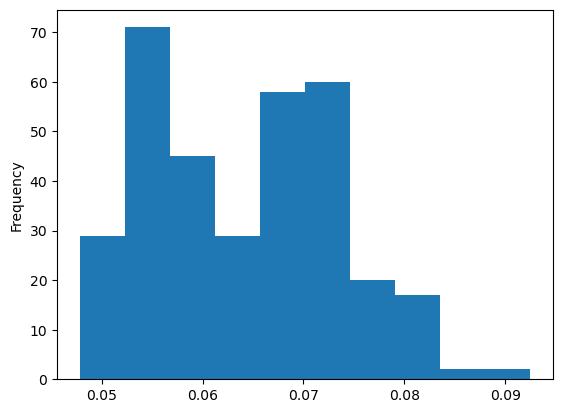

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / "dataset.csv")
df.depr_prev.plot.hist();

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 66 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   COUNTYFP                                                   333 non-null    int64  
 1   year                                                       333 non-null    int64  
 2   surface_latent_heat_flux_sum                               333 non-null    float64
 3   surface_net_solar_radiation_sum                            333 non-null    float64
 4   surface_solar_radiation_downwards_sum                      333 non-null    float64
 5   surface_thermal_radiation_downwards_sum                    333 non-null    float64
 6   evaporation_from_bare_soil_sum                             333 non-null    float64
 7   evaporation_from_the_top_of_canopy_sum                     333 non-null    float64
 8   evaporatio

In [12]:
lm = LinearRegression()

X = df.drop(columns=["depr_prev", "NDVI", "NDVI_binary", "NO2_column_number_density"])
y = df["depr_prev"]     

X_sm = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(X, y)

results = sm.OLS(y, X_sm).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              depr_prev   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     7.886
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           8.97e-33
Time:                        16:29:45   Log-Likelihood:                 1239.0
No. Observations:                 333   AIC:                            -2364.
Df Residuals:                     276   BIC:                            -2147.
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------